# 06 · Propuesta de uso

**Fase CRISP-DM:** despliegue, como propuesta **no ejecutada** dentro de los sistemas de Trufi Association.

**Objetivo.** Convertir la brecha por zona en productos concretos y reproducibles para priorizar el mapeo voluntario,
y documentar los datos, la infraestructura y el procedimiento para una eventual implementación.

| | |
|---|---|
| **Entradas** | `resultados/05_evaluacion/brecha_por_zona.csv` y los `metricas.json` de las fases 02 y 05 |
| **Entregables** | `resultados/06_propuesta/predicciones_por_zona.csv` y `.geojson`, `zonas_prioritarias.csv`, `mapa_brecha.html` |

## 1. Configuración

In [1]:
import sys
from pathlib import Path

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ))

In [2]:
from src.entorno import *  # noqa: F403
from src import espacial, evaluacion as ev

import geopandas as gpd

FASE = "06_propuesta"
limpiar_salidas(FASE)
M = {}
tiempo = cronometro()

## 2. Carga de la brecha
**Tipo de datos:** tabulares por zona (observado, esperado, brecha y cobertura).

In [3]:
brecha = pd.read_csv(config.RESULTADOS / "05_evaluacion" / "brecha_por_zona.csv")
evaluacion = leer_metricas("05_evaluacion")
W_OBS = leer_metricas("02_preprocesamiento")["w_obs_semanas"]
assert len(brecha) == evaluacion["zonas_brecha"], "La brecha no coincide con la evaluación"
print(f"{len(brecha):,} zonas | técnica {evaluacion['tecnica_evaluada']} | W_obs = {W_OBS} semanas")

1,381 zonas | técnica B3 | W_obs = 81.143 semanas


## 3. Regla de priorización
**Tipo de datos:** categóricos derivados (acción sugerida por zona).

La regla está declarada en `config.py` y combina la brecha con la cobertura de la red mapeada:

| Acción | Condición | Lectura para Trufi |
|---|---|---|
| `mapear` | brecha negativa y sin trazado GTFS a ≤ `COBERTURA_M` | posible ruta existente que no está en la aplicación |
| `revisar` | brecha negativa con trazado GTFS cercano | la ruta está mapeada, pero quizás desactualizada o poco útil |
| `sin_brecha` | brecha ≥ 0 | la zona consulta al menos lo esperado |

Las **zonas prioritarias** son las `TOP_K` con la brecha más negativa entre las de acción `mapear`.

In [4]:
negativa, cubierta = brecha["gap_pearson"] < 0, brecha["gtfs_covered"] == 1
brecha["action"] = np.select([negativa & ~cubierta, negativa & cubierta], ["mapear", "revisar"], "sin_brecha")
universo = brecha[brecha["action"] == "mapear"] if config.PRIORIDAD_SOLO_SIN_COBERTURA else brecha[negativa]
prioritarias = ev.top_k(universo)
rango = {c: i for i, c in enumerate(prioritarias, start=1)}
brecha["priority_rank"] = brecha["h3_cell"].map(rango).astype("Int64")
brecha["action"].value_counts()

action
mapear        598
sin_brecha    458
revisar       325
Name: count, dtype: int64

## 4. Predicciones por zona
**Tipo de datos:** tabulares y espaciales (un registro y un polígono por zona).

Archivo principal para Trufi: una fila por zona del modelo con lo observado, lo esperado (total y por semana
observada), la brecha, la cobertura y la acción sugerida. Se entrega en CSV y en GeoJSON para abrirlo en un SIG.

In [5]:
brecha["observed_week"] = brecha["observed"] / W_OBS
columnas = ["h3_cell", "lat", "lon", "municipality", "population", "observed", "expected", "observed_week",
            "expected_week", "gap_pearson", "ratio_obs_exp", "unmet_demand", "gtfs_covered", "dist_trazado_m",
            "partition", "action", "priority_rank"]
pred = brecha[columnas].sort_values("h3_cell", ignore_index=True)
guardar_tabla(pred.round(4), "predicciones_por_zona", FASE)
geo = espacial.geo_zonas(pred.round(4))
geo.to_file(config.RESULTADOS / FASE / "predicciones_por_zona.geojson", driver="GeoJSON")
print(f"{len(pred):,} zonas → predicciones_por_zona.csv y .geojson")

1,381 zonas → predicciones_por_zona.csv y .geojson


## 5. Zonas prioritarias
**Tipo de datos:** tabulares (lista ordenada de 20 zonas).

Lista para revisión en terreno, con enlace directo a cada zona en OpenStreetMap. Se mide qué parte de la demanda no
resuelta estimada de las zonas sin cobertura concentran estas zonas.

La lista trae dos columnas para registrar la visita. `field_result` parte en `sin_visitar` y toma una de las categorías
de `CATEGORIAS_TERRENO`; `field_notes` es texto libre. Hoy **no existe verificación en terreno**: con estos registros se
podrá medir la proporción de zonas donde la brecha señalaba una ruta real.

| `field_result` | Significado |
|---|---|
| `ruta_no_mapeada` | hay una ruta que opera y no está en la aplicación |
| `ruta_mapeada_correcta` | la ruta ya estaba mapeada y es correcta |
| `sin_transporte` | no se encontró transporte público |
| `sin_visitar` | todavía sin visita |

In [6]:
top = pred[pred["priority_rank"].notna()].sort_values("priority_rank").copy()
top["osm_url"] = [f"https://www.openstreetmap.org/?mlat={a:.5f}&mlon={b:.5f}#map=16/{a:.5f}/{b:.5f}" for a, b in zip(top["lat"], top["lon"], strict=True)]
top["field_result"], top["field_notes"] = config.CATEGORIAS_TERRENO[-1], ""
guardar_tabla(top[["priority_rank", "h3_cell", "municipality", "population", "observed_week", "expected_week",
                   "gap_pearson", "unmet_demand", "dist_trazado_m", "lat", "lon", "osm_url",
                   "field_result", "field_notes"]].round(3), "zonas_prioritarias", FASE)
M.update({"zonas_prioritarias": len(top), "zonas_mapear": int((pred["action"] == "mapear").sum()),
          "zonas_revisar": int((pred["action"] == "revisar").sum()), "zonas_sin_brecha": int((pred["action"] == "sin_brecha").sum()),
          "poblacion_prioritarias": int(top["population"].sum()),
          "pct_demanda_no_resuelta_sin_cobertura_top_k": round(float(top["unmet_demand"].sum()
                                                                   / pred.loc[pred["action"] == "mapear", "unmet_demand"].sum() * 100), 1),
          "municipios_prioritarias": int(top["municipality"].nunique())})
print({k: M[k] for k in M})
top[["priority_rank", "municipality", "population", "observed_week", "expected_week", "gap_pearson"]].round(2)

{'zonas_prioritarias': 20, 'zonas_mapear': 598, 'zonas_revisar': 325, 'zonas_sin_brecha': 458, 'poblacion_prioritarias': 20370, 'pct_demanda_no_resuelta_sin_cobertura_top_k': 79.7, 'municipios_prioritarias': 4}


,priority_rank,municipality,population,observed_week,expected_week,gap_pearson
359,1,Cochabamba,1352,4.65,77.56,-74.58
89,2,Cochabamba,1911,0.69,52.50,-64.41
341,3,Cochabamba,734,0.33,42.07,-57.97
345,4,Cochabamba,2945,2.83,16.14,-29.83
179,5,Colcapirhua,1107,2.58,13.32,-26.52
128,6,Cochabamba,1294,0.87,8.31,-23.23
344,7,Cochabamba,943,1.60,9.19,-22.55
592,8,Quillacollo,1426,2.03,9.25,-21.37
346,9,Cochabamba,624,0.32,6.07,-21.03
95,10,Colcapirhua,1120,3.72,11.35,-20.39


PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/06_propuesta/figuras/zonas_prioritarias.png')

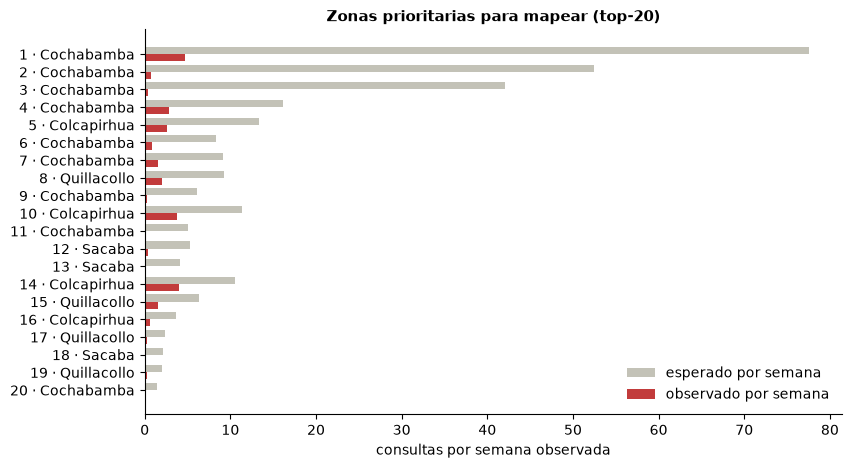

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(top))[::-1]
ax.barh(y + 0.2, top["expected_week"], 0.4, color=GRIS, label="esperado por semana")
ax.barh(y - 0.2, top["observed_week"], 0.4, color=ROJO, label="observado por semana")
ax.set_yticks(y, [f"{int(r)} · {m}" for r, m in zip(top["priority_rank"], top["municipality"], strict=True)])
ax.set(xlabel="consultas por semana observada", title=f"Zonas prioritarias para mapear (top-{config.TOP_K})")
ax.legend(frameon=False)
guardar_figura(fig, "zonas_prioritarias", FASE)

⏱ entregables: 3.5 s (acumulado 4 s)


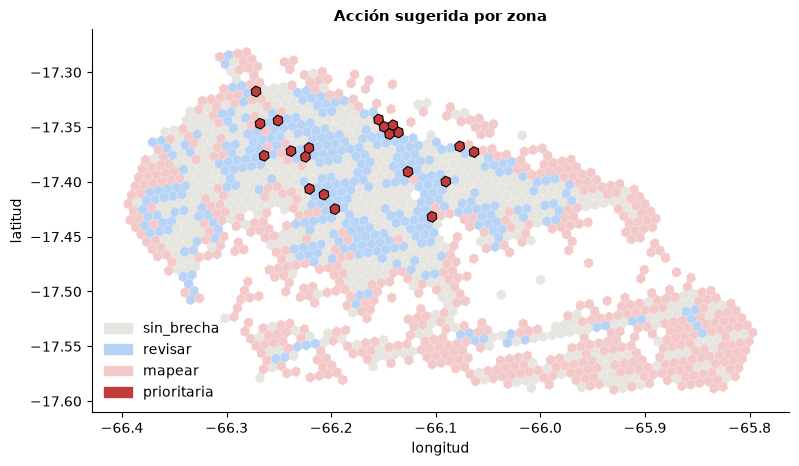

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
colores = {"sin_brecha": "#e6e5df", "revisar": "#b7d3f6", "mapear": "#f3c9c9"}
for accion, color in colores.items():
    geo[geo["action"] == accion].plot(ax=ax, color=color, edgecolor="white", linewidth=0.1)
geo[geo["priority_rank"].notna()].plot(ax=ax, color=ROJO, edgecolor="black", linewidth=0.8)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in [*colores.values(), ROJO]],
          labels=[*colores, "prioritaria"], frameon=False, loc="lower left")
ax.set(xlabel="longitud", ylabel="latitud", title="Acción sugerida por zona")
guardar_figura(fig, "mapa_acciones", FASE)
tiempo("entregables")

## 6. Mapa interactivo
**Tipo de datos:** espaciales (mapa web).

`mapa_brecha.html` se abre en cualquier navegador sin instalar nada: colorea cada zona por su brecha, resalta las
zonas prioritarias y muestra al pasar el cursor lo observado, lo esperado por semana y la cobertura.

In [9]:
mapa = ev.mapa_brecha(geo, prioritarias)
mapa.save(config.RESULTADOS / FASE / "mapa_brecha.html")
print("mapa_brecha.html guardado")

mapa_brecha.html guardado


## 7. Propuesta de implementación (no ejecutada)

**Productos reproducibles.** Los tres entregables de esta fase, regenerados de punta a punta con los seis notebooks.

**Datos requeridos.**

| Fuente | Formato | Frecuencia sugerida |
|---|---|---|
| Consultas de Trufi App | exportaciones CSV semanales en `data/raw/` (mismo esquema) | semanal o mensual |
| Población | Kontur Population (`.gpkg.gz`, H3 res 8) | por edición publicada |
| Red mapeada | feed GTFS de Trufi en `data/raw/gtfs/` | cada vez que se publique el feed |

**Infraestructura.** Un equipo con Python ≥ 3.12 y `uv`; el pipeline completo tarda unos minutos y cabe en memoria de
un portátil. No requiere servidores: los entregables son archivos que se comparten (CSV, GeoJSON y HTML).

**Procedimiento.**
1. Copiar las nuevas exportaciones, el GTFS vigente y la edición de Kontur a `data/raw/`.
2. Ejecutar `uv sync` y los seis notebooks en orden (comando en el `README.md`).
3. Revisar que todas las verificaciones pasen y comparar `metricas.json` con la edición anterior.
4. Entregar `zonas_prioritarias.csv` y `mapa_brecha.html` a los coordinadores de mapeo.
5. Registrar el resultado de la visita a cada zona en `field_result` (`ruta_no_mapeada`, `ruta_mapeada_correcta`,
   `sin_transporte`) para medir la precisión real de la priorización en la siguiente edición.

**Monitoreo.** Alertar si el Spearman de la brecha frente a la edición anterior cae por debajo de 0,8, si la
calibración global sale de [0,9; 1,1] o si aparecen semanas faltantes o parciales nuevas.

**Riesgos.** Cambios en la adopción de la aplicación (crecimiento desigual entre zonas), actualizaciones del feed GTFS
que alteren la cobertura, cambios metodológicos de Kontur y la sensibilidad de la lista a la técnica de estimación
(medida en la evaluación).

## 8. Verificaciones

### 8.1 La lista cumple la regla
Todas las zonas prioritarias tienen brecha negativa, no tienen trazado cercano y son las de brecha más negativa.

In [10]:
assert len(top) == config.TOP_K and (top["gap_pearson"] < 0).all() and (top["gtfs_covered"] == 0).all()
assert top["gap_pearson"].max() <= pred.loc[(pred["action"] == "mapear") & pred["priority_rank"].isna(), "gap_pearson"].min()
print("Top-20: brecha negativa, sin cobertura y ordenadas por brecha")

Top-20: brecha negativa, sin cobertura y ordenadas por brecha


### 8.2 Coherencia con la evaluación
Los entregables conservan todas las zonas y el total esperado de la evaluación, y el GeoJSON se lee de vuelta.

In [11]:
assert len(pred) == evaluacion["zonas_brecha"] and pred["h3_cell"].is_unique
assert round(pred["unmet_demand"].sum()) == evaluacion["demanda_no_resuelta_total"]
assert len(gpd.read_file(config.RESULTADOS / FASE / "predicciones_por_zona.geojson")) == len(pred)
print("Entregables coherentes con resultados/05_evaluacion/metricas.json")

Entregables coherentes con resultados/05_evaluacion/metricas.json


### 8.3 Plantilla de registro en terreno
La lista se lee de vuelta con las 20 zonas y las columnas de registro, todas con una categoría válida y sin visitar.

In [12]:
lista = pd.read_csv(config.RESULTADOS / FASE / "zonas_prioritarias.csv", keep_default_na=False)
assert len(lista) == config.TOP_K and {"field_result", "field_notes"} <= set(lista.columns)
assert lista["field_result"].isin(config.CATEGORIAS_TERRENO).all()
assert (lista["field_result"] == config.CATEGORIAS_TERRENO[-1]).all(), "Hay visitas registradas antes de tiempo"
print(f"{len(lista)} zonas con plantilla de terreno; categorías: {config.CATEGORIAS_TERRENO}")

20 zonas con plantilla de terreno; categorías: ['ruta_no_mapeada', 'ruta_mapeada_correcta', 'sin_transporte', 'sin_visitar']


## 9. Cierre

In [13]:
M.update({"top_k": config.TOP_K, "cobertura_m": config.COBERTURA_M, "w_obs_semanas": W_OBS, "semilla": config.SEMILLA})
ruta = guardar_metricas(FASE, M)
tiempo("cierre")
print(f"{len(M)} métricas → {ruta.relative_to(config.RAIZ)}")

⏱ cierre: 1.3 s (acumulado 5 s)
11 métricas → resultados/06_propuesta/metricas.json
